In [1]:
# !pip install wordcloud

In [2]:
# !pip install --upgrade threadpoolctl

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction import text
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

In [34]:
import matplotlib.dates as mdates
from sklearn.preprocessing import StandardScaler

# Speeches

## Data Loading and Initial Verification

In [2]:
# Load the cleaned speech dataset
bsp = pd.read_csv('../00 Cleaned Dataset/01 speech dataset/bsp_speech_dataset.csv')
bsp.head()

,index,Title,Date,Location,Occasion,Speaker,Role,Text,Len,Link,last_name,year
0,0,Staying on Track in 2020: Sustaining Positive ...,2020-03-03,"Dusit Thani Manila, Makati City",The Manila Times 11th Business Forum,Benjamin E. Diokno,Governor,"The Manila Times President and CEO, Mr. Dante ...",2442,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
1,1,Finding Opportunities in a Borderless World,2020-02-28,"El Nido, Palawan",13th Annual FMAP Convention,Benjamin E. Diokno,Governor,To the officers and members of the Fund Manage...,2672,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
2,2,Gearing up for the Road Ahead: With Foresight ...,2020-02-27,Sofitel Philippine Plaza Hotel,17th Professional Insurance and Financial Advi...,Benjamin E. Diokno,Governor,Officers and members of the Professional Insur...,2922,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
3,3,A Strong Nation Amid A Slowing and Volatile World,2020-02-06,"Shangri-La at the Fort, Taguig",General Membership Meeting and Economic Briefing,Benjamin E. Diokno,Governor,Officers and members of the Management Associa...,2177,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020
4,4,Welcome Dinner Remarks,2020-01-31,Philippine International Convenion Center,BSP-BI Bilateral Meeting,Benjamin E. Diokno,Governor,"Governor Perry, Deputy Governors, colleagues f...",357,https://www.bsp.gov.ph/SitePages/MediaAndResea...,Diokno,2020


In [3]:
# Checking the unique values of the 'Speaker' column

bsp['Speaker'].unique()

array(['Benjamin E. Diokno', 'Amando M. Tetangco, Jr.',
       'Maria Almasara Cyd N. Tuano-Amador', 'Nestor A. Espenilla, Jr.',
       'Chuchi G. Fonacier', 'Diwa C. Guinigundo', 'Rafael Buenaventura',
       'Alberto V. Reyes', 'Gabriel Singson'], dtype=object)

In [4]:
bsp['last_name'].unique()

array(['Diokno', 'Tetangco', 'Tuano-Amador', 'Espenilla', 'Fonacier',
       'Guinigundo', 'Buenaventura', 'Reyes', 'Singson'], dtype=object)

In [5]:
bsp['Len'].describe()

count     673.000000
mean     1367.665676
std       666.708769
min       171.000000
25%       810.000000
50%      1349.000000
75%      1843.000000
max      3674.000000
Name: Len, dtype: float64

## Temporal Analysis (speeches over time)

### frequency trends

<Axes: title={'center': 'Number of speeches by year'}, xlabel='year'>

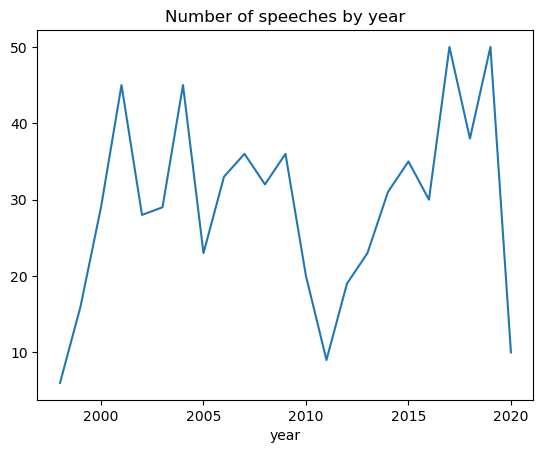

In [6]:
bsp.groupby('year').size().plot(title='Number of speeches by year')

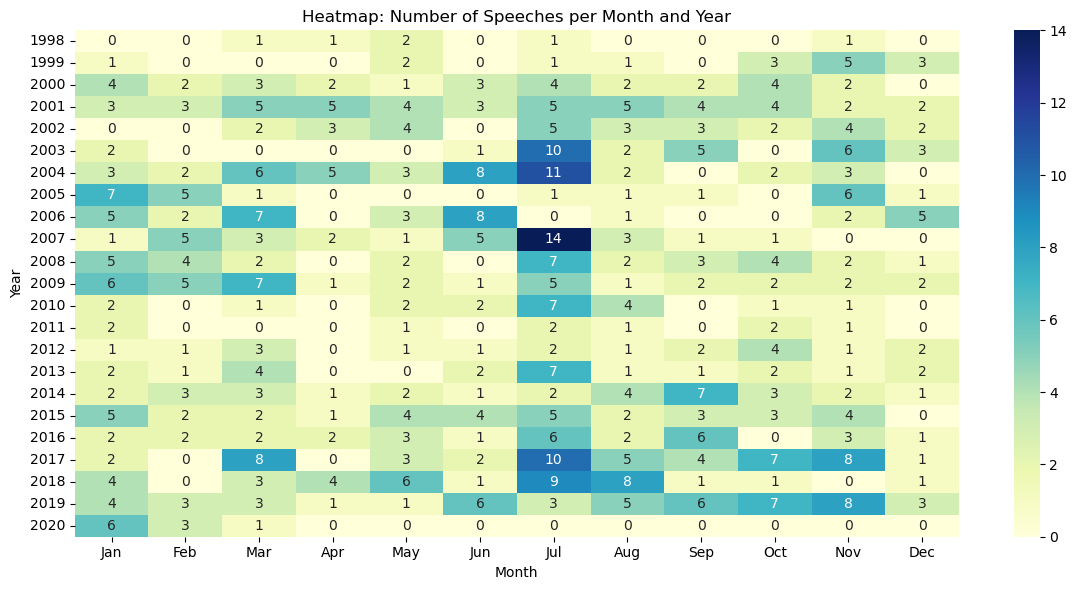

In [7]:
# Heatmap of Number of Speeches per Month and Year

bsp['Date'] = pd.to_datetime(bsp['Date'], dayfirst=True, format='mixed')

# Convert numeric month to abbreviated month name (e.g., Jan, Feb)
bsp['month'] = bsp['Date'].dt.strftime('%b')

# Ensure months stay in chronological order (Jan -> Dec)
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
bsp['month'] = pd.Categorical(bsp['month'], categories=month_order, ordered=True)

# Count speeches by year and month
speech_count = bsp.groupby(['year', 'month'], observed=False).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(speech_count, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Heatmap: Number of Speeches per Month and Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

### volume trends

<Axes: title={'center': 'Total Length of Speeches per Year'}, xlabel='year', ylabel='Total Length'>

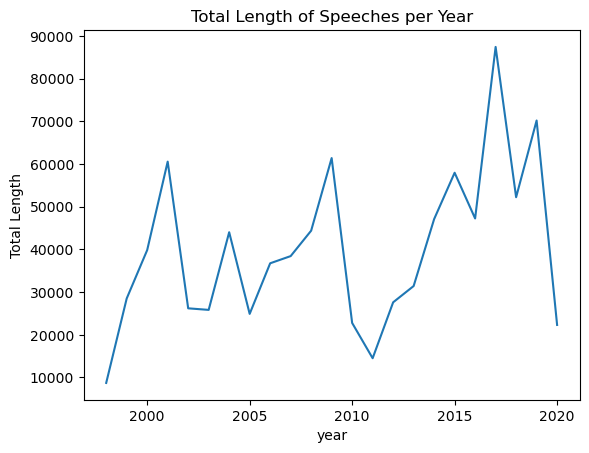

In [8]:
bsp.groupby('year')['Len'].sum().plot(title='Total Length of Speeches per Year', ylabel='Total Length')

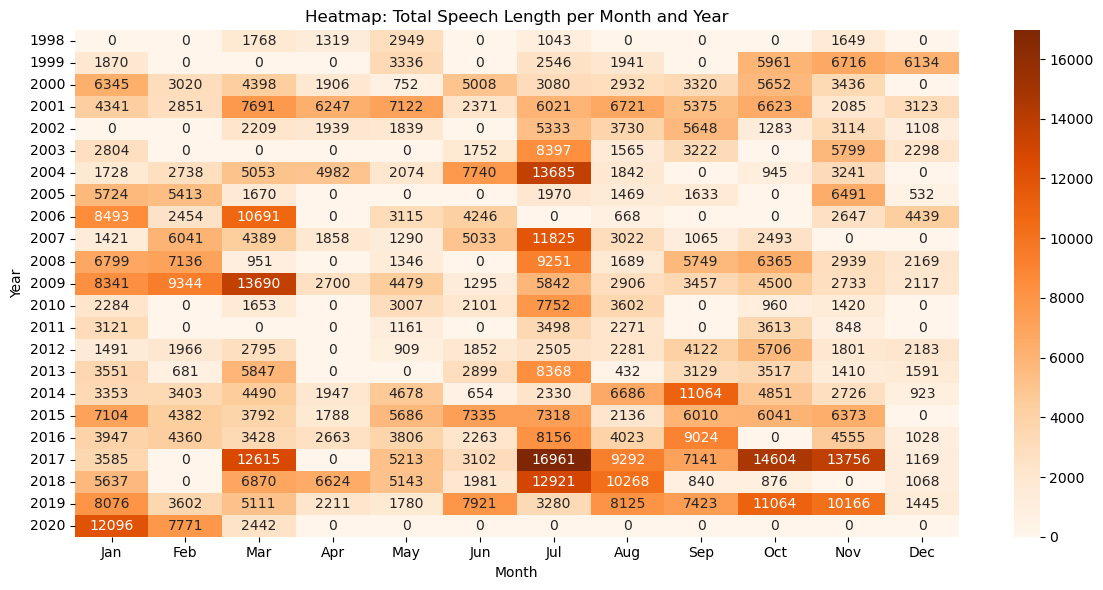

In [9]:
# Length of Speeches Heatmap
speech_length = bsp.groupby(['year', 'month'])['Len'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(speech_length, annot=True, fmt='.0f', cmap='Oranges')
plt.title('Heatmap: Total Speech Length per Month and Year')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

## Speaker and Administration Analysis

### productivity by individual

      last_name    N
7      Tetangco  329
0  Buenaventura  200
2     Espenilla   75
1        Diokno   53
6       Singson   10
4    Guinigundo    2
8  Tuano-Amador    2
3      Fonacier    1
5         Reyes    1


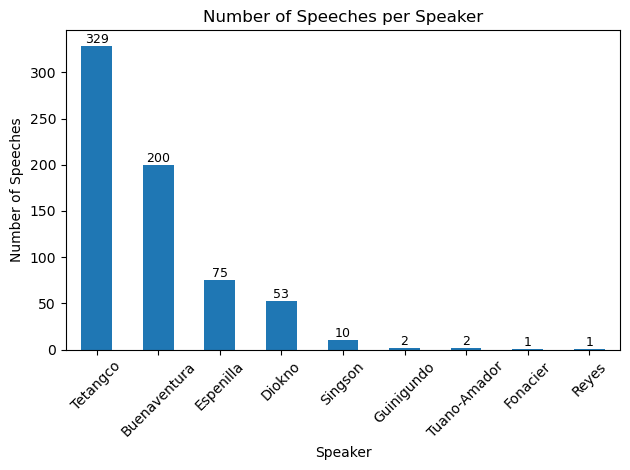

In [10]:
# Group and sort by number of speeches
speaker_counts = bsp.groupby('last_name').size().reset_index(name='N').sort_values('N', ascending=False)

# Print the values
print(speaker_counts)

# Plot
ax = speaker_counts.plot.bar(x='last_name', y='N', legend=False)

# Add title and labels
plt.title("Number of Speeches per Speaker")
plt.xlabel("Speaker")
plt.ylabel("Number of Speeches")

# Add count on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

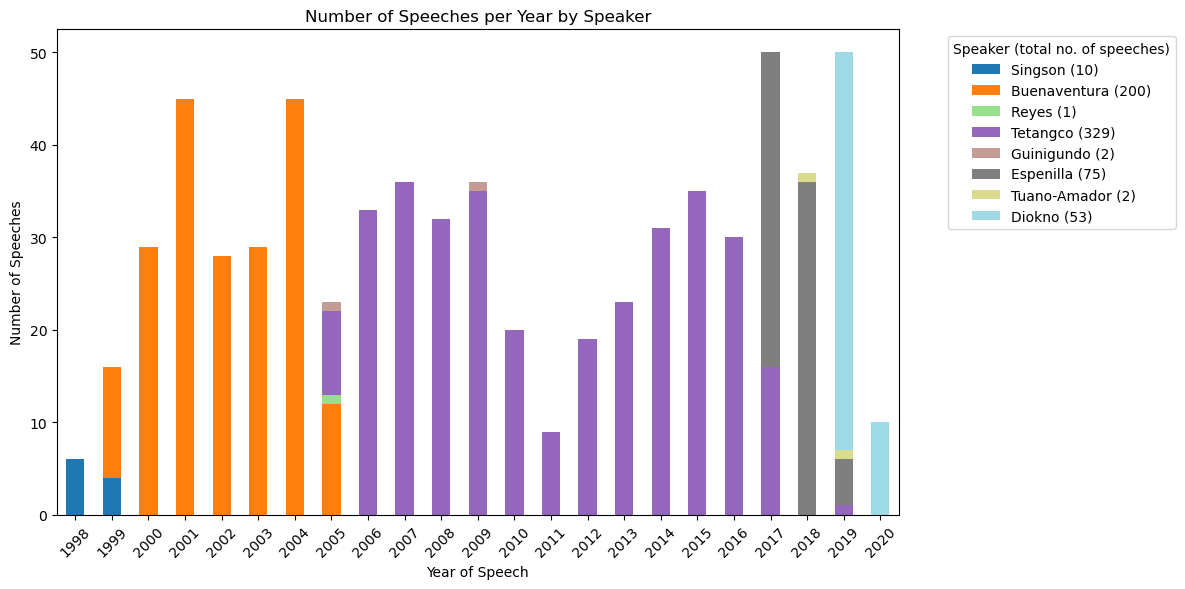

In [11]:
# Group data by year and last_name

# Define the desired order of speakers for the legend
speaker_order = ['Singson', 'Buenaventura', 'Reyes', 'Tetangco', 'Guinigundo', 'Espenilla', 'Tuano-Amador', 'Diokno']

# Convert 'last_name' to a categorical type with the specified order
bsp['last_name'] = pd.Categorical(bsp['last_name'], categories=speaker_order, ordered=True)

speech_counts = bsp.groupby(['year', 'last_name']).size().reset_index(name='count')
pivot_df = speech_counts.pivot(index='year', columns='last_name', values='count').fillna(0)

# Calculate total speeches per speaker
total_speeches_per_speaker = bsp['last_name'].value_counts()

# Create custom legend labels
legend_labels = []
for speaker in speaker_order:
    total_count = total_speeches_per_speaker.get(speaker, 0)
    legend_labels.append(f"{speaker} ({int(total_count)})")

# The categorical type on 'last_name' ensures the order of columns in pivot_df

ax = pivot_df.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab20')

plt.title('Number of Speeches per Year by Speaker')
plt.xlabel('Year of Speech')
plt.ylabel('Number of Speeches')
plt.legend(title='Speaker (total no. of speeches)', bbox_to_anchor=(1.05, 1), loc='upper left', labels=legend_labels)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

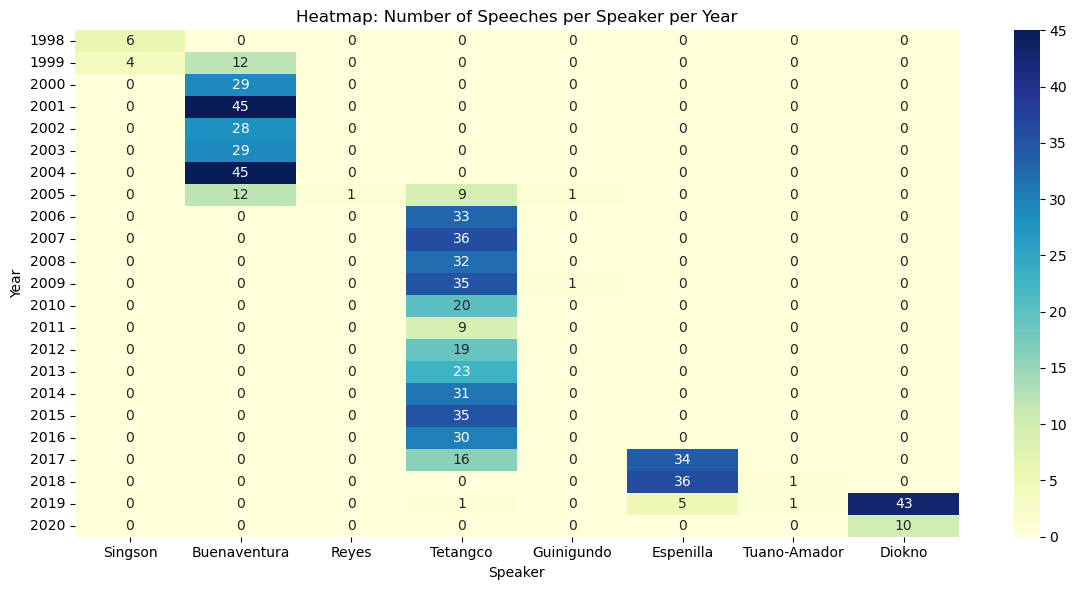

In [12]:
speaker_order = ['Singson', 'Buenaventura', 'Reyes', 'Tetangco', 'Guinigundo', 'Espenilla', 'Tuano-Amador', 'Diokno']
# guinigundo is gitna ni tetangco;; guinigundo speeches dates: 6/19/09, 11/11/05
# reyes is gitna ni buenaventura
bsp['last_name'] = pd.Categorical(bsp['last_name'], categories=speaker_order, ordered=True)

# Count number of speeches by year and speaker
speech_count = bsp.groupby(['year', 'last_name']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(speech_count, annot=True, fmt='d', cmap='YlGnBu')

plt.title('Heatmap: Number of Speeches per Speaker per Year')
plt.xlabel('Speaker')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

### workload by individual

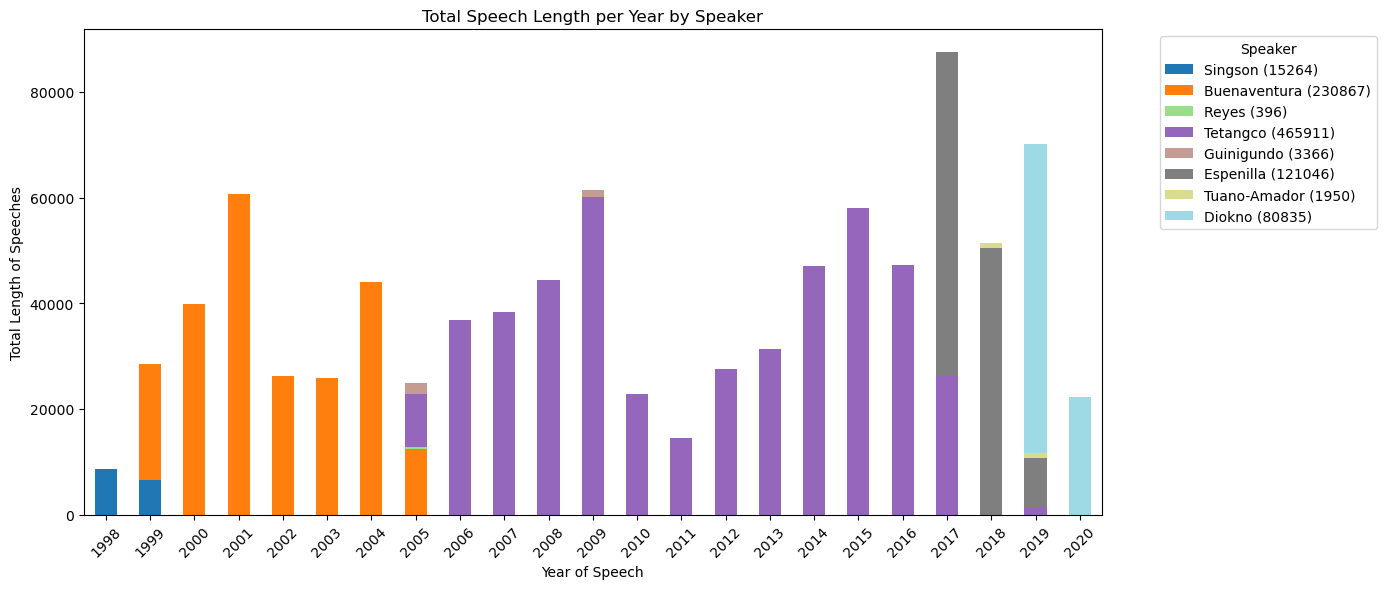

In [13]:
speaker_order = ['Singson', 'Buenaventura', 'Reyes', 'Tetangco', 'Guinigundo', 'Espenilla', 'Tuano-Amador', 'Diokno']
bsp['last_name'] = pd.Categorical(bsp['last_name'], categories=speaker_order, ordered=True)


# Group by year and last_name, then sum 'Len' (speech length)
lengths_by_year_speaker = bsp.groupby(['year', 'last_name'], observed=False)['Len'].sum().reset_index()

# Pivot: rows = year, columns = speakers, values = total length
pivot_len_df = lengths_by_year_speaker.pivot(index='year', columns='last_name', values='Len').fillna(0)

# Calculate total lengths per speaker for the legend labels
total_len_per_speaker = bsp.groupby('last_name', observed=False)['Len'].sum()

legend_labels = []
for speaker in speaker_order:
    total_len = total_len_per_speaker.get(speaker, 0)
    legend_labels.append(f"{speaker} ({int(total_len)})")

# Plot
pivot_len_df.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')

plt.title('Total Speech Length per Year by Speaker')
plt.xlabel('Year of Speech')
plt.ylabel('Total Length of Speeches')
plt.legend(title='Speaker', bbox_to_anchor=(1.05, 1), loc='upper left', labels=legend_labels)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

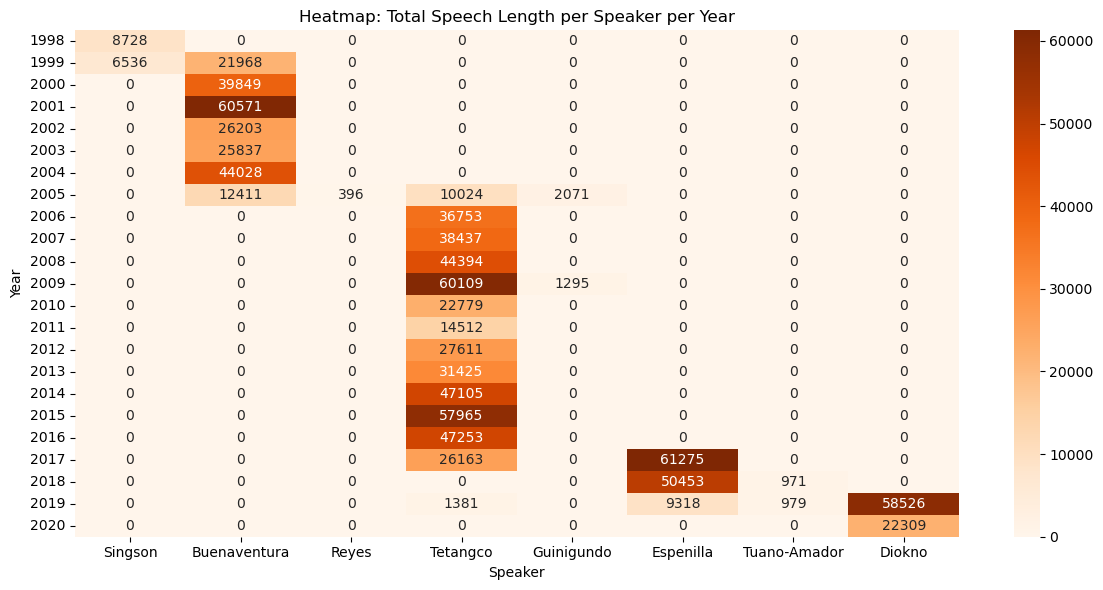

In [14]:
# Sum total speech lengths by year and speaker
speech_length = bsp.groupby(['year', 'last_name'])['Len'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(speech_length, annot=True, fmt='.0f', cmap='Oranges')

plt.title('Heatmap: Total Speech Length per Speaker per Year')
plt.xlabel('Speaker')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

## Speech Length Distribution

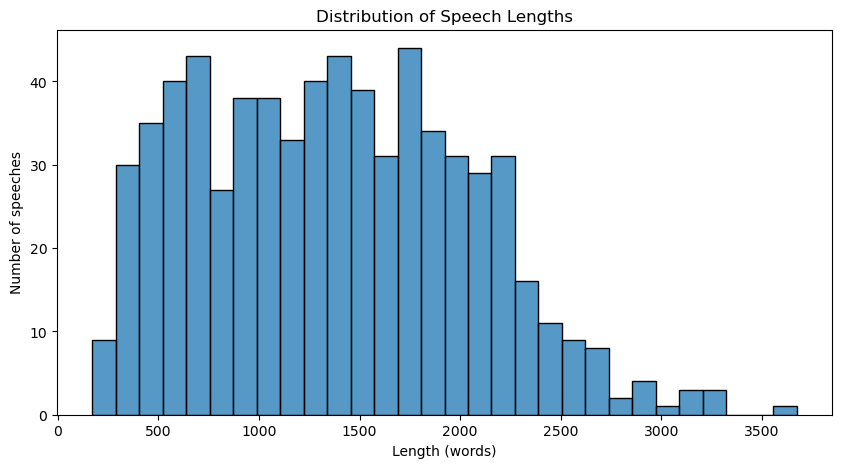

In [15]:
# Histogram of speech lengths
plt.figure(figsize=(10, 5))
sns.histplot(bsp['Len'], bins=30)
plt.xlabel("Length (words)")
plt.ylabel("Number of speeches")
plt.title("Distribution of Speech Lengths")
plt.show()

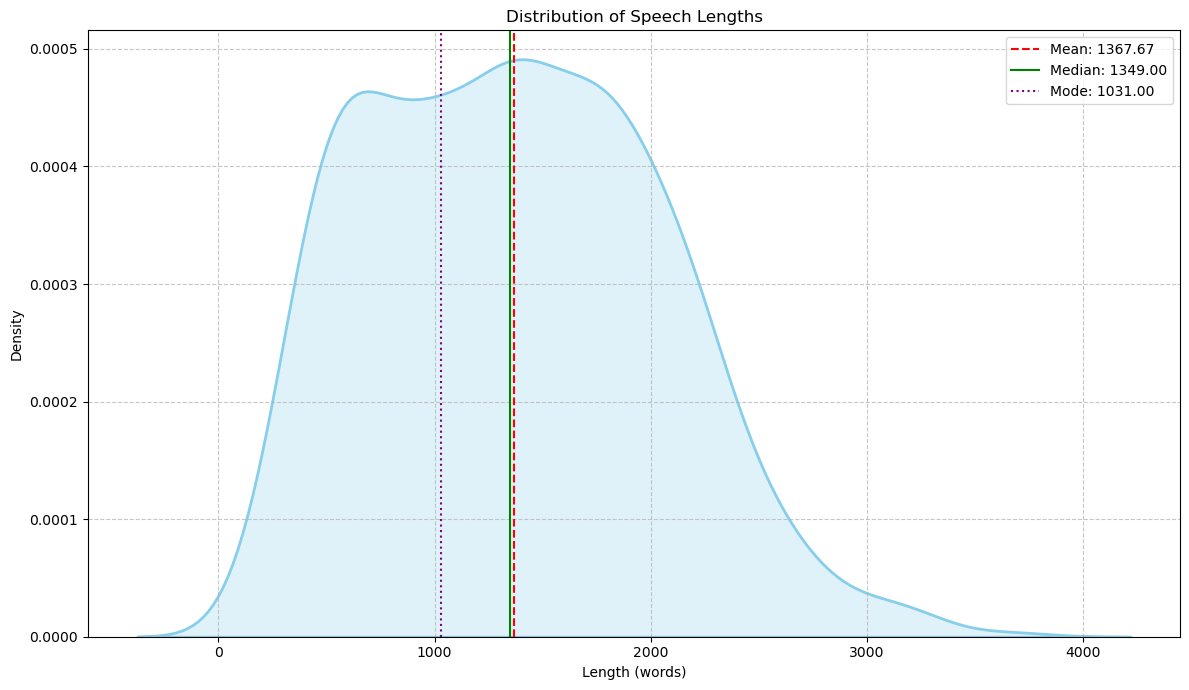

In [16]:
plt.figure(figsize=(12, 7))
sns.kdeplot(bsp['Len'], fill=True, color='skyblue', linewidth=2)

# Calculate statistics
mean_len = bsp['Len'].mean()
median_len = bsp['Len'].median()
mode_len_series = bsp['Len'].mode()
mode_len = mode_len_series[0] if not mode_len_series.empty else None # Get the first mode if exists

# Add vertical lines for mean, median, mode
plt.axvline(mean_len, color='red', linestyle='--', label=f'Mean: {mean_len:.2f}')
plt.axvline(median_len, color='green', linestyle='-', label=f'Median: {median_len:.2f}')
if mode_len is not None:
    plt.axvline(mode_len, color='purple', linestyle=':', label=f'Mode: {mode_len:.2f}')

# Add labels and title
plt.title('Distribution of Speech Lengths')
plt.xlabel('Length (words)')
plt.ylabel('Density')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

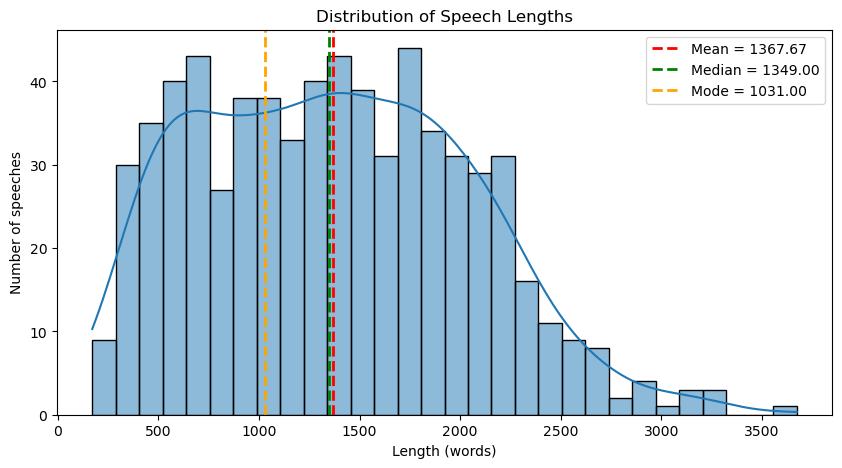

In [17]:
# Compute summary statistics
mean_len = bsp['Len'].mean()
median_len = bsp['Len'].median()

# Raw mode (may return multiple values, so take the first one)
mode_len = bsp['Len'].mode().iloc[0]

# Histogram + density line
plt.figure(figsize=(10, 5))
sns.histplot(bsp['Len'], bins=30, kde=True)

# Reference lines
plt.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f"Mean = {mean_len:.2f}")
plt.axvline(median_len, color='green', linestyle='--', linewidth=2, label=f"Median = {median_len:.2f}")
plt.axvline(mode_len, color='orange', linestyle='--', linewidth=2, label=f"Mode = {mode_len:.2f}")

plt.xlabel("Length (words)")
plt.ylabel("Number of speeches")
plt.title("Distribution of Speech Lengths")
plt.legend()
plt.show()

## Exploratory Text Analysis (ETA)

### visual vocabulary

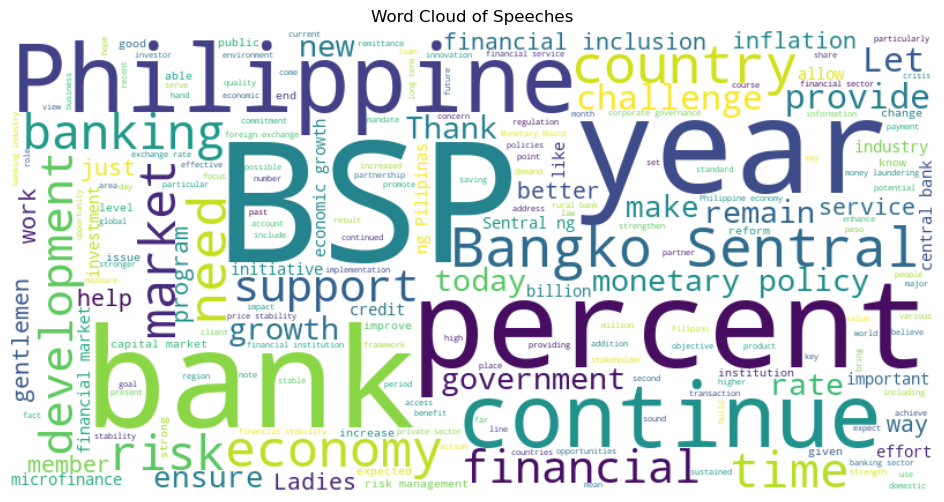

In [18]:
# Word cloud
text_combined = ' '.join(bsp['Text'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white',
                      stopwords=text.ENGLISH_STOP_WORDS).generate(text_combined)
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Speeches")
plt.show()

### clustering

In [19]:
# TF-IDF + KMeans Clustering
vectorizer = TfidfVectorizer(max_df=0.95, min_df=5, stop_words='english')
tfidf_matrix = vectorizer.fit_transform(bsp['Text'].dropna())
kmeans = KMeans(n_clusters=4, random_state=42)
bsp['cluster'] = np.nan
bsp.loc[bsp['Text'].notna(), 'cluster'] = kmeans.fit_predict(tfidf_matrix)

C:\Programming\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


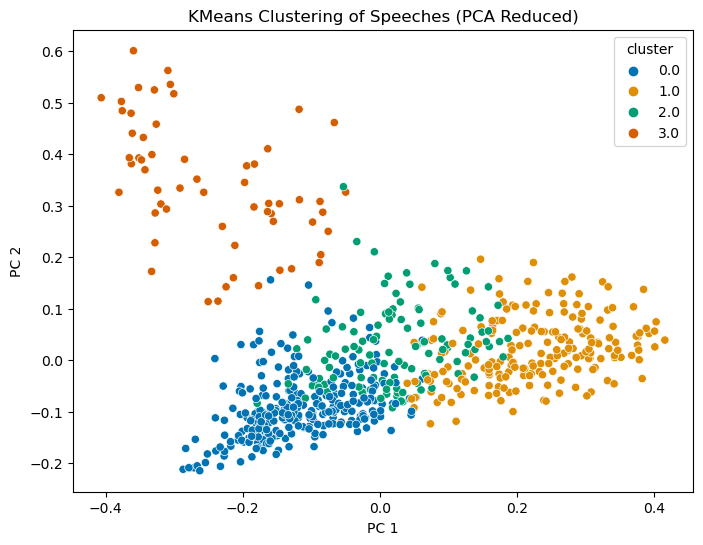

In [20]:
# To interpret KMeans visually

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8,6))
sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=bsp.loc[bsp['Text'].notna(), 'cluster'], palette='colorblind')
plt.title('KMeans Clustering of Speeches (PCA Reduced)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.show()

In [21]:
# Extracting top keywords per cluster

terms = vectorizer.get_feature_names_out()

# For each cluster, get top N terms
top_n = 15
for i in range(kmeans.n_clusters):
    print(f"\nCluster {i} Top Terms:")
    center = kmeans.cluster_centers_[i]
    top_indices = center.argsort()[::-1][:top_n]
    for idx in top_indices:
        print(f"  {terms[idx]}")


Cluster 0 Top Terms:
  financial
  bsp
  sentral
  bangko
  banking
  bank
  ng
  inclusion
  economic
  banks
  monetary
  money
  pilipinas
  central
  country

Cluster 1 Top Terms:
  percent
  inflation
  bsp
  financial
  growth
  policy
  market
  economy
  economic
  monetary
  year
  banking
  banks
  rate
  external

Cluster 2 Top Terms:
  market
  financial
  banking
  banks
  capital
  governance
  risk
  bank
  bsp
  corporate
  industry
  standards
  percent
  baiphil
  thrift

Cluster 3 Top Terms:
  microfinance
  rural
  banks
  banking
  rbap
  financial
  microentrepreneurs
  cma
  services
  clients
  poverty
  credit
  bsp
  poor
  industry


In [22]:
# Showing sample representative speeches by picking samples closest to each cluster center

from sklearn.metrics import pairwise_distances_argmin_min

closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, tfidf_matrix.toarray())

for i, idx in enumerate(closest):
    print(f"\nRepresentative speech for Cluster {i}:")
    print(bsp.iloc[idx]['Text'][:500])  # Preview first 500 chars


Representative speech for Cluster 0:
Magandang, magandang umaga.... at maligayang anibersaryo sa ating lahat dito sa Bangko Sentral ng Pilipinas! Ladies and gentlemen of the BSP. Let me begin my remarks with a question for you: Is there a reason for us to celebrate the 18th anniversary of the BSP?............. I agree! In fact, there are many reasons for us to celebrate this milestone. In particular, the BSP has established a solid track record in promoting monetary and financial stability in our country. This has contributed to th

Representative speech for Cluster 1:
Executive Director Robert Sears, executives of the American Chamber of Commerce of the Philippines, distinguished guests, ladies and gentlemen, good morning to all of you. It is a pleasure to be here this morning to share with you the experience of the Bangko Sentral ng Pilipinas in responding to the challenges posed by the recent global financial crisis, taking into consideration the current global and domestic scenari

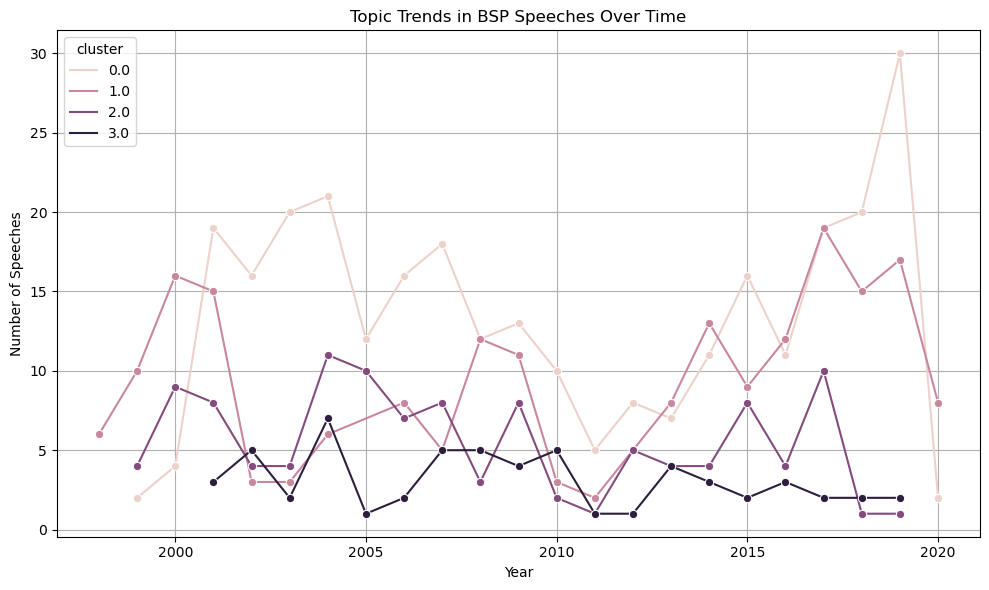

In [23]:
# Assigning cluster labels to the dataset
bsp.loc[bsp['Text'].notna(), 'cluster'] = kmeans.predict(tfidf_matrix)

# Visualize cluster trends over time
cluster_year_counts = bsp.groupby(['year', 'cluster']).size().reset_index(name='count')

plt.figure(figsize=(10,6))
sns.lineplot(data=cluster_year_counts, x='year', y='count', hue='cluster', marker='o')
plt.title('Topic Trends in BSP Speeches Over Time')
plt.ylabel('Number of Speeches')
plt.xlabel('Year')
plt.grid(True)
plt.tight_layout()
plt.show()

### topic modeling

In [24]:
# LDA Topic Modeling
lda = LatentDirichletAllocation(n_components=8, random_state=123, max_iter=10, learning_method='batch')
lda.fit(tfidf_matrix)

LatentDirichletAllocation(n_components=8, random_state=123)

In [25]:
# Top words per topic
terms = vectorizer.get_feature_names_out()
topics = []
for idx, topic in enumerate(lda.components_):
    top_terms = [terms[i] for i in topic.argsort()[:-16:-1]]
    topics.append((f"Topic {idx+1}", ', '.join(top_terms)))

topics_df = pd.DataFrame(topics, columns=["Topic", "Top Words"])
topics_df

,Topic,Top Words
0,Topic 1,"isang, mahalagang, vohra, sanjiv, lamang, bans..."
1,Topic 2,"isang, mahalagang, vohra, sanjiv, lamang, bans..."
2,Topic 3,"isang, mahalagang, vohra, sanjiv, lamang, bans..."
3,Topic 4,"citi, cma, gawad, kalinga, mcpi, microentrepre..."
4,Topic 5,"financial, bsp, banking, banks, market, percen..."
5,Topic 6,"isang, mahalagang, vohra, sanjiv, lamang, bans..."
6,Topic 7,"isang, mahalagang, vohra, sanjiv, lamang, bans..."
7,Topic 8,"isang, mahalagang, vohra, sanjiv, lamang, bans..."


### structural similarity

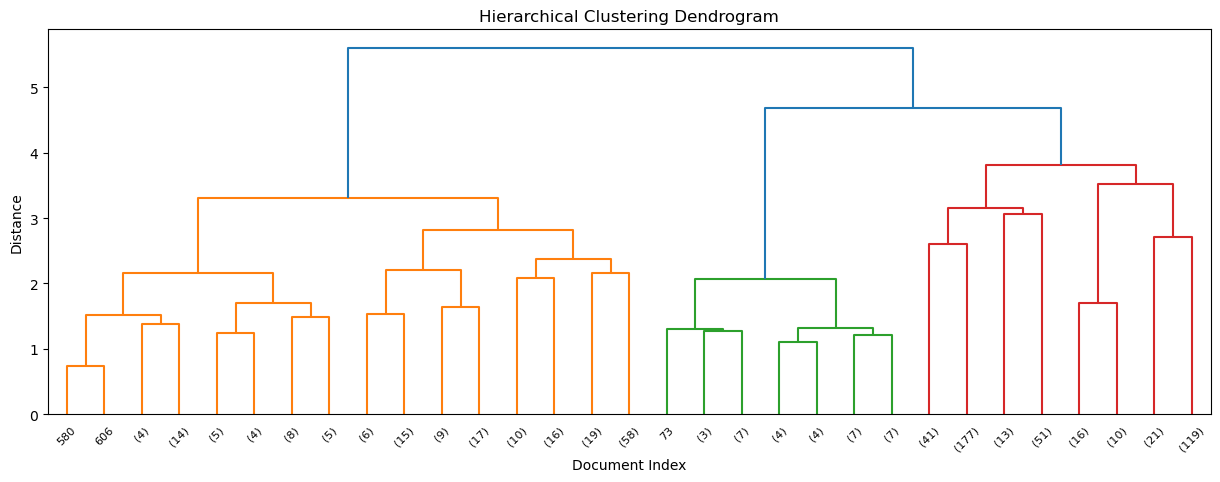

In [26]:
# Hierarchical Clustering
from scipy.spatial.distance import pdist
condensed_dist = pdist(tfidf_matrix.toarray(), 'euclidean')
linkage_matrix = linkage(condensed_dist, method='ward')
plt.figure(figsize=(15, 5))
dendrogram(linkage_matrix, truncate_mode='level', p=4)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Document Index")
plt.ylabel("Distance")
plt.show()

# INTEREST RATE

In [27]:
# Load the dataset
df_interest_rate = pd.read_csv('../00 Cleaned Dataset/03 economic dataset/others/withGDP_Econ_Dataset_with_orig_and_yoy.csv')

df_interest_rate

,Date,Interbank Call Loan Rate,Real GDP,CPI,Wholesale Price,Industrial Production,Intl Trade Merch Exports,Intl Trade Merch Imports,FX Rate,Real GDP_yoy_pct,CPI_yoy_pct,Wholesale Price_yoy_pct,Industrial Production_yoy_pct,Intl Trade Merch Exports_yoy_pct,Intl Trade Merch Imports_yoy_pct,FX Rate_yoy_pct
0,2000-04-01,8.846467,1653.296021,46.564396,49.112316,47.951805,122463.656250,112343.710938,41.188400,-2.357231,-7.020871,-6.729131,-17.399658,-12.036585,-23.742827,-17.927507
1,2000-05-01,8.878472,1729.789429,46.706940,48.932911,42.576923,109947.960938,104178.578125,41.806300,-3.164755,-6.912874,-7.776837,-13.532396,-2.567846,-33.220726,-17.278897
2,2000-06-01,9.765625,1729.789429,46.801968,49.246868,48.261353,122662.843750,101988.859375,42.648900,-3.164755,-6.899814,-7.808568,-9.661012,-6.583343,-31.310551,-17.167382
3,2000-07-01,10.367560,1729.789429,47.277115,49.471127,51.778942,145549.312500,106494.289062,44.355667,-3.164755,-6.747894,-8.993398,-7.965606,9.435560,-27.748429,-16.662567
4,2000-08-01,10.617062,1709.412964,47.514687,49.964493,49.274418,143163.296875,119013.664062,44.897652,-3.016611,-6.890136,-8.912509,-6.984505,3.627590,-22.218756,-13.637926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289,2024-06-01,6.508536,5539.082520,125.599998,138.300003,99.541405,366273.812500,639752.375000,58.696278,-5.201989,-1.257861,-3.354300,0.156579,-9.978752,5.064100,4.147902
290,2024-07-01,6.515650,5539.082520,125.599998,138.800003,96.161621,326938.343750,581487.062500,58.484478,-5.201989,-1.335432,-2.937061,-2.802676,-17.900334,-9.984433,3.052086
291,2024-08-01,6.511924,5316.054199,126.500000,139.000000,102.081268,365493.531250,650692.000000,57.193450,-3.848556,-0.939700,-3.000700,0.708049,-12.558166,-2.813053,-0.103186
292,2024-09-01,6.471885,5316.054199,126.599998,139.100006,98.493027,384723.031250,635113.187500,56.071286,-3.848556,-1.478601,-2.317407,-1.851898,-5.517658,0.023121,-2.059045


## Descriptive Statistics


In [28]:
# Original Values
orig_cols = ['Interbank Call Loan Rate', 'Real GDP', 'CPI', 'Wholesale Price', 
             'Industrial Production', 'Intl Trade Merch Exports', 'Intl Trade Merch Imports', 'FX Rate']

print("Descriptive Statistics (Original Levels):")
df_interest_rate[orig_cols].describe()

Descriptive Statistics (Original Levels):


,Interbank Call Loan Rate,Real GDP,CPI,Wholesale Price,Industrial Production,Intl Trade Merch Exports,Intl Trade Merch Imports,FX Rate
count,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000
mean,5.081207,3319.699536,83.292822,94.892819,75.758036,225500.763765,300649.699458,49.351971
std,2.519460,1170.398584,21.997096,24.737639,16.575743,70318.170237,152883.523378,4.678526
min,1.535187,1653.296021,46.564396,48.932911,13.077386,109947.960938,101988.859375,40.671100
25%,2.572710,2297.796875,65.116527,77.222950,66.367443,174104.921875,196544.957031,44.962981
50%,4.669373,3129.775635,85.068581,100.000000,77.344486,202880.937500,227564.648438,49.855209
75%,7.050462,4384.760620,99.992895,112.099998,86.010918,280154.890625,404724.742188,52.807895
max,15.105903,5884.528320,126.599998,139.500000,108.341713,454896.562500,694898.812500,58.824700


In [29]:
# Year-over-Year % Change
yoy_cols = ['Real GDP_yoy_pct', 'CPI_yoy_pct', 'Wholesale Price_yoy_pct', 
            'Industrial Production_yoy_pct', 'Intl Trade Merch Exports_yoy_pct', 
            'Intl Trade Merch Imports_yoy_pct', 'FX Rate_yoy_pct']

print("Descriptive Statistics (YoY % Change):")
df_interest_rate[yoy_cols].describe()

Descriptive Statistics (YoY % Change):


,Real GDP_yoy_pct,CPI_yoy_pct,Wholesale Price_yoy_pct,Industrial Production_yoy_pct,Intl Trade Merch Exports_yoy_pct,Intl Trade Merch Imports_yoy_pct,FX Rate_yoy_pct
count,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000,294.000000
mean,-4.646343,-3.861009,-4.032376,3.678296,-2.904868,-4.942071,-0.653714
std,3.921790,1.941534,3.717936,52.935662,14.572486,19.181717,6.431152
min,-10.747527,-9.536313,-17.405356,-84.172084,-39.955694,-58.676202,-17.927507
25%,-6.404029,-4.931217,-6.270426,-9.246092,-12.527501,-16.032165,-4.850260
50%,-5.588301,-3.545698,-3.351201,-4.066569,-3.758911,-6.266908,-1.253353
75%,-4.307985,-2.613334,-1.967705,3.080638,4.058656,2.315739,3.723078
max,20.347393,0.374180,12.577958,491.715967,74.745872,176.607099,19.483633


## Correlation Matrix


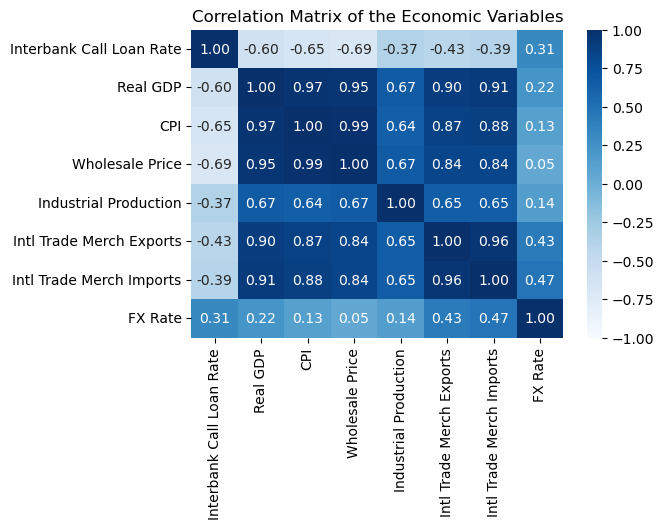

In [30]:
# Correlation matrix for the macroeconomic variables
corr_matrix = df_interest_rate[['Interbank Call Loan Rate', 'Real GDP', 'CPI', 'Wholesale Price', 'Industrial Production', 'Intl Trade Merch Exports', 'Intl Trade Merch Imports', 'FX Rate']].corr()

plt.figure(figsize=(6, 4))


# Use a blue-only colormap (light to dark blue)
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=sns.color_palette("Blues", as_cmap=True),
    vmin=-1, vmax=1,
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix of the Economic Variables")
plt.show()

## Standardized Time Series Plots


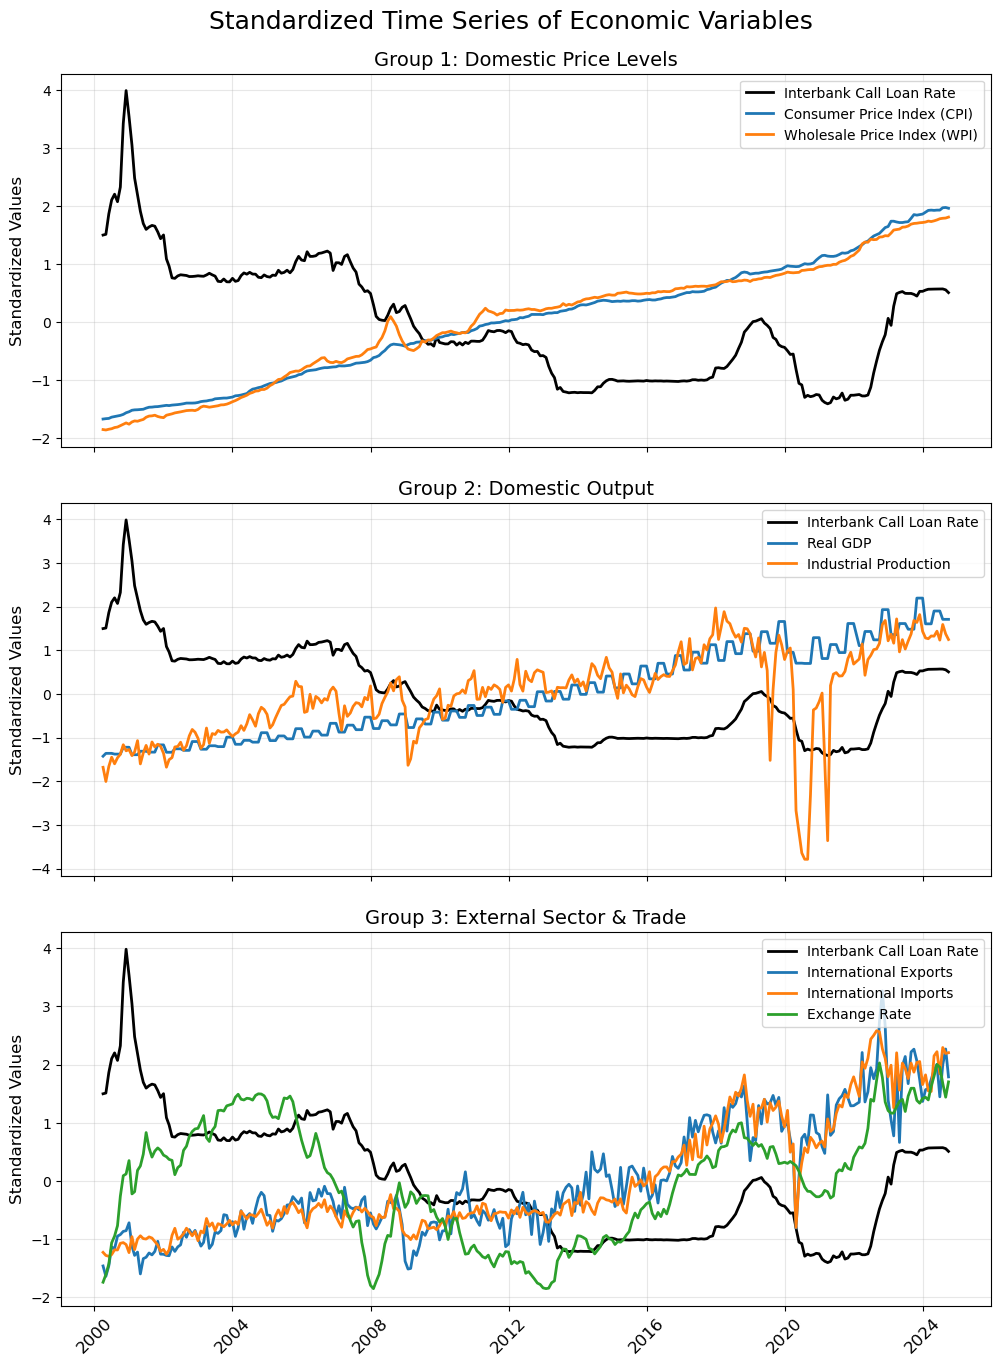

In [36]:
# Standardize columns
cols_to_standardize = ['Interbank Call Loan Rate', 'CPI', 'Wholesale Price', 
                       'Real GDP', 'Industrial Production', 
                       'Intl Trade Merch Exports', 'Intl Trade Merch Imports', 'FX Rate']
z_cols = [c + '_z' for c in cols_to_standardize]

scaler = StandardScaler()
df_interest_rate[z_cols] = scaler.fit_transform(df_interest_rate[cols_to_standardize])

# Create Figure with 3 Subplots
fig, axes = plt.subplots(3, 1, figsize=(12, 16), sharex=True)
fig.suptitle('Standardized Time Series of Economic Variables', fontsize=18, y=0.92)

# Plot A: Domestic Price Levels vs Interest Rates
axes[0].plot(df_interest_rate['Date'], df_interest_rate['Interbank Call Loan Rate_z'], label='Interbank Call Loan Rate', linewidth=2, color='black')
axes[0].plot(df_interest_rate['Date'], df_interest_rate['CPI_z'], label='Consumer Price Index (CPI)', linewidth=2)
axes[0].plot(df_interest_rate['Date'], df_interest_rate['Wholesale Price_z'], label='Wholesale Price Index (WPI)', linewidth=2)
axes[0].set_title('Group 1: Domestic Price Levels', fontsize=14)
axes[0].set_ylabel('Standardized Values', fontsize=12)
axes[0].legend(loc='upper right')
axes[0].grid(alpha=0.3)

# Plot B: Domestic Output vs Interest Rates
axes[1].plot(df_interest_rate['Date'], df_interest_rate['Interbank Call Loan Rate_z'], label='Interbank Call Loan Rate', linewidth=2, color='black')
axes[1].plot(df_interest_rate['Date'], df_interest_rate['Real GDP_z'], label='Real GDP', linewidth=2)
axes[1].plot(df_interest_rate['Date'], df_interest_rate['Industrial Production_z'], label='Industrial Production', linewidth=2)
axes[1].set_title('Group 2: Domestic Output', fontsize=14)
axes[1].set_ylabel('Standardized Values', fontsize=12)
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

# Plot C: External Sector vs Interest Rates
axes[2].plot(df_interest_rate['Date'], df_interest_rate['Interbank Call Loan Rate_z'], label='Interbank Call Loan Rate', linewidth=2, color='black')
axes[2].plot(df_interest_rate['Date'], df_interest_rate['Intl Trade Merch Exports_z'], label='International Exports', linewidth=2)
axes[2].plot(df_interest_rate['Date'], df_interest_rate['Intl Trade Merch Imports_z'], label='International Imports', linewidth=2)
axes[2].plot(df_interest_rate['Date'], df_interest_rate['FX Rate_z'], label='Exchange Rate', linewidth=2)
axes[2].set_title('Group 3: External Sector & Trade', fontsize=14)
axes[2].set_ylabel('Standardized Values', fontsize=12)
axes[2].legend(loc='upper right')
axes[2].grid(alpha=0.3)

# Format the X-axis
axes[2].xaxis.set_major_locator(mdates.YearLocator(4))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45, fontsize=12)

plt.subplots_adjust(hspace=0.15)
plt.show()
